# Reach for Change — Part 2: Predicting Donor Response
### DSML Group Project 2025/2026 — `DSML_GroupXX`


**How to use this notebook.** It runs end-to-end as-is and produces a valid baseline
Kaggle submission. Every section has a **`TODO`** marking where your group must
*improve and justify* the default choice. The defaults are deliberately simple — the
marks are in the reasoning you add, the EDA insight behind each decision, and the
discussion. Do not keep any technique you cannot explain in the defense.

## Group Member Contribution

> **`TODO`** Fill in each member's contributions and estimated % (must sum to 100%).

| Member | Contributions | % |
|---|---|---|
| _Name 1_ | _..._ | _XX%_ |
| _Name 2_ | _..._ | _XX%_ |
| _Name 3_ | _..._ | _XX%_ |
| _Name 4_ | _..._ | _XX%_ |

## Abstract

> **`TODO`** Write 200–300 words *after* finishing the project: context, goals,
> what you did, main results, conclusions.

# I. Introduction

> **`TODO`** Briefly state the business problem (CSA wants to contact *fewer, better-
> targeted* donors), the goal (predict `TARGET_B`), and an overview of your process.

**Model assessment approach.** We use **stratified 5-fold cross-validation** for model
selection. The dataset (~13.5k rows) is mid-sized, so cross-validation makes better use
of the data than a single holdout, and stratification preserves the ~25% positive rate
in every fold. The Kaggle test set is our final unseen check.

**Evaluation metric.** The primary metric is the **binary F1 score**, matching the
Kaggle leaderboard. Accuracy is unsuitable here: with ~25% positives, a model that
predicts "no donation" for everyone reaches ~75% accuracy and F1 = 0. We report
precision and recall alongside F1 because they carry the business meaning — precision
is outreach efficiency, recall is donor coverage.

## Setup

In [76]:
# --- Core libraries (vanilla scikit-learn only; no XGBoost/LightGBM/AutoML) ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import f_classif, RFE
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, roc_curve)

pd.set_option("display.max_columns", 50)



In [77]:
# --- Configuration ---
RANDOM_SEED = 42
N_FOLDS = 5
DATA_DIR = Path("../data/data_raw")   # TODO: point this to the folder holding the 4 CSV files

TARGET = "TARGET_B"
ID_COL = "CONTROL_NUMBER"

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

In [78]:
# --- Load data ---
# Training features and the target arrive in separate files; merge them on CONTROL_NUMBER.
features = pd.read_csv(DATA_DIR / "donors_descriptive.csv")
target   = pd.read_csv(DATA_DIR / "donors_train_target.csv")
train = features.merge(target, on=ID_COL, how="inner")

test = pd.read_csv(DATA_DIR / "test.csv")

print(f"train: {train.shape}  |  test: {test.shape}")
print(f"positive rate: {train[TARGET].mean():.3f}")
train.head()

train: (13560, 41)  |  test: (5812, 40)
positive rate: 0.250


,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
0,61745,4.0,2.000000,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,28.0,18.0,18.0,10.0,0.0,52.00000,17.0,25.0,92.0,0.0,12827.0,A,0.00,17.50,0.0,0.000,2.0,0.154,0.0,2,T,NaN,1
1,112703,3.0,-2.341107,NaN,F,1.0,1.0,U,NaN,15.0,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.0,24.0,24.0,7.0,0.0,64.86817,31.0,39.0,73.0,0.0,7787.0,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1
2,166437,4.0,0.000000,74.0,F,7.0,3.0,H,4.0,10.0,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.0,15.0,15.0,8.0,0.0,26.00000,39.0,38.0,84.0,1.0,13965.0,NaN,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0
3,170621,4.0,4.000000,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.0,16.0,16.0,13.0,0.0,48.00000,30.0,44.0,NaN,1.0,24123.0,A,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0
4,44428,6.0,3.000000,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.0,17.0,17.0,13.0,0.0,52.00000,12.0,66.0,90.0,1.0,15008.0,N,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0


# II. Data Exploration and Preprocessing

## II.1 Exploratory Data Analysis

> **`TODO`** Explore the data and extract insights that *drive a preprocessing decision*.
> The rubric rewards EDA you act on — avoid decorative plots. Suggested questions:
> - Which features have the most missing values, and how will you handle each?
> - Are there outliers in the gift-amount / income features?
> - Which features look most related to `TARGET_B`?
> - Are the categorical features clean (consistent categories, no rare-noise levels)?

In [79]:
# Quick structural overview (working starter — extend with your own EDA below)
print("=== dtypes ===")
print(train.dtypes.value_counts())

print("\n=== target balance ===")
print(train[TARGET].value_counts())

print("\n=== missing values (train) ===")
miss = train.drop(columns=[ID_COL, TARGET]).isna().mean().sort_values(ascending=False)
print((miss[miss > 0] * 100).round(1).astype(str) + " %")

=== dtypes ===
float64    34
object      5
int64       2
Name: count, dtype: int64

=== target balance ===
TARGET_B
0    10170
1     3390
Name: count, dtype: int64

=== missing values (train) ===
WEALTH_RATING                  46.2 %
DONOR_AGE                      26.5 %
INCOME_GROUP                   24.2 %
MONTHS_SINCE_LAST_PROM_RESP     3.2 %
SES                             2.1 %
PCT_ATTRIBUTE3                  2.1 %
URBANICITY                      2.1 %
RECENT_CARD_RESPONSE_COUNT      2.1 %
MONTHS_SINCE_FIRST_GIFT         2.1 %
PCT_ATTRIBUTE1                  2.0 %
LIFETIME_MAX_GIFT_AMT           2.0 %
RECENT_STAR_STATUS              2.0 %
MONTHS_SINCE_LAST_GIFT          2.0 %
RECENT_CARD_RESPONSE_PROP       2.0 %
LIFETIME_PROM                   2.0 %
NUMBER_PROM_12                  2.0 %
LIFETIME_GIFT_AMOUNT            2.0 %
LIFETIME_CARD_PROM              2.0 %
CHILDREN                        2.0 %
RECENT_AVG_GIFT_AMT             2.0 %
FILE_CARD_GIFT                  2.0 %
HOME_O

### II.1.1. Missingness

#### Missingness Patterns

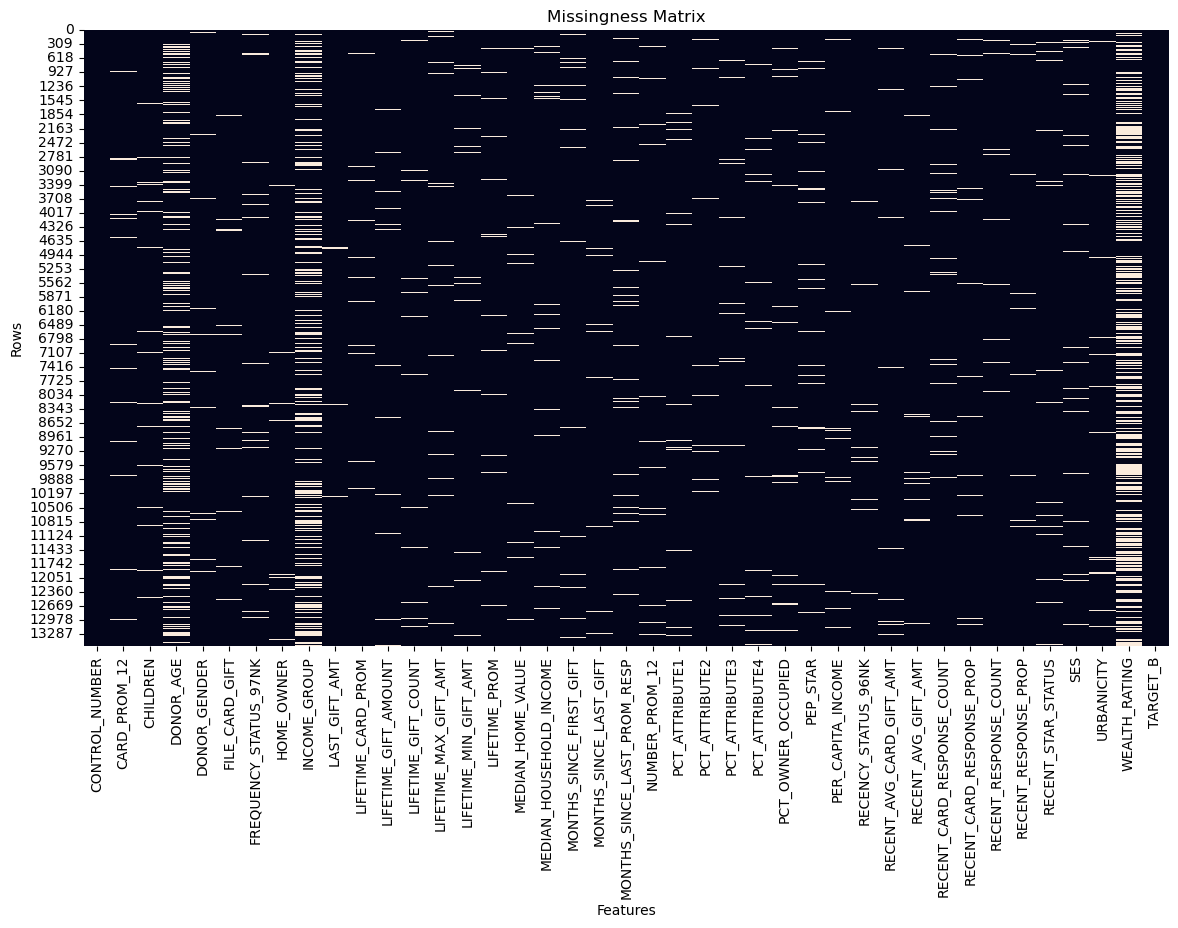

In [80]:
# Visual Missingness pattern inspection
plt.figure(figsize=(14, 8))
sns.heatmap(train.isna(), cbar=False)
plt.title("Missingness Matrix")
plt.xlabel("Features")
plt.ylabel("Rows")
plt.show()

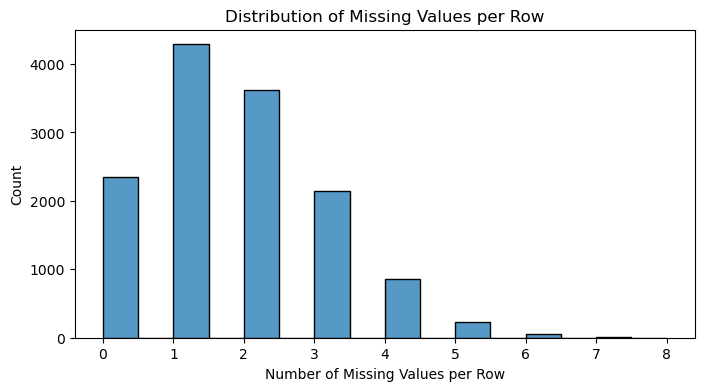

In [81]:
# Number of missing values by row
plt.figure(figsize=(8, 4))
sns.histplot(train.isna().sum(axis=1), bins=16)
plt.title("Distribution of Missing Values per Row")
plt.xlabel("Number of Missing Values per Row")
plt.show()

#### **Findings**
- **No missingness patterns where found**


### II.1.2 Data Quality

In [82]:
# Data Quality Function
def create_quality_summary(data, columns, impossible_mask):
    summary = pd.DataFrame({
        "column_name": columns,
        "dtype": data.dtypes.values,
        "nan_count": data.isna().sum().values,
        "nan_%": (data.isna().mean() * 100).round(2).values,
        "i_count": impossible_mask.sum().values,
        "i_%": (impossible_mask.mean() * 100).round(2).values,
        "i_nr_unique": [
            data.loc[impossible_mask[col], col].dropna().nunique()
            for col in columns
        ],
        "non_valid_count": (
            data.isna().sum().values + impossible_mask.sum().values
        ),
        "non_valid_%": (
            (data.isna().mean().values + impossible_mask.mean().values) * 100
        ).round(2),
        "i_values": [
            sorted(data.loc[impossible_mask[col], col].dropna().unique())
            for col in columns
        ],
    })

    return summary

#### Categorical Binary

##### Data Quality

In [83]:
# Categorical Binary features
col_catbin = ['PEP_STAR','RECENT_STAR_STATUS']

# dataset with only categorical binary features
train_catbin = train[col_catbin]

# mask to identify impossible values
col_catbin_impossible_mask = (~train_catbin.isin([0, 1]) & train_catbin.notna())

# creating summary to check data quality
train_catbin_summary = create_quality_summary(
    train_catbin,
    col_catbin,
    col_catbin_impossible_mask
)

print("Categorical Binary Features Summary:")
print("    nan prefix: missing values")
print("    i prefix: impossible values")
print("    non_valid prefix: sum of missing and impossible values")
train_catbin_summary.sort_values('non_valid_count', ascending=False)

Categorical Binary Features Summary:
    nan prefix: missing values
    i prefix: impossible values
    non_valid prefix: sum of missing and impossible values


,column_name,dtype,nan_count,nan_%,i_count,i_%,i_nr_unique,non_valid_count,non_valid_%,i_values
1,RECENT_STAR_STATUS,float64,275,2.03,1370,10.10,23,1645,12.13,"[-7.80641563113009, 2.0, 3.0, 4.0, 5.0, 6.0, 7..."
0,PEP_STAR,float64,265,1.95,133,0.98,2,398,2.94,"[-0.5298607009385796, 2.0036085611535746]"


##### **Preprocess Decision**
- **Findings**
    - **`RECENT_STAR_STATUS`** 
        - Low % missing values
        - 10.1% impossible values
    - **`PEP_STAR`** 
        - With low missing count and low impossible values
- **Preprocess decision:**
    - Remove impossible values
    - Cast as correct type (int64)

#### Categorical Nominal

##### Data Quality

In [84]:
# Categorical Nominal features
col_catnom = ['HOME_OWNER','DONOR_GENDER','RECENCY_STATUS_96NK','URBANICITY']

# From Business context and dataset inspection we know the valid values for each feature
col_catnom_valid_values = {
    'HOME_OWNER':['H', 'U'],
    'DONOR_GENDER':['F', 'M'],
    'RECENCY_STATUS_96NK':['A', 'E', 'F', 'L', 'N', 'S'],
    'URBANICITY':['U', 'C', 'T', 'R', 'S']
}

# dataset with only categorical Nominal features
train_catnom = train[col_catnom]

# mask to identify impossible values
col_catnom_impossible_mask = pd.DataFrame({
    col: (~train_catnom[col].isin(col_catnom_valid_values[col]) & train_catnom[col].notna())
    for col in col_catnom
})

# creating summary to check data quality
train_catnom_summary = create_quality_summary(
    train_catnom,
    col_catnom,
    col_catnom_impossible_mask
)

print("Categorical Nominal Features Summary")
print("    nan prefix: missing values")
print("    i prefix: impossible values")
print("    non_valid prefix: sum of missing and impossible values")
train_catnom_summary.sort_values('non_valid_count', ascending=False)

Categorical Nominal Features Summary
    nan prefix: missing values
    i prefix: impossible values
    non_valid prefix: sum of missing and impossible values


,column_name,dtype,nan_count,nan_%,i_count,i_%,i_nr_unique,non_valid_count,non_valid_%,i_values
1,DONOR_GENDER,object,257,1.90,705,5.20,1,962,7.09,[U]
3,URBANICITY,object,278,2.05,295,2.18,1,573,4.23,[?]
0,HOME_OWNER,object,268,1.98,0,0.00,0,268,1.98,[]
2,RECENCY_STATUS_96NK,object,266,1.96,0,0.00,0,266,1.96,[]


##### **Preprocess Decision**
- **Findings:**
    - **`DONOR_GENDER`**
        - `'U'` value with missing context value (Unknown? Undetermined?), low frequency(1.90%), can be replaced with `nan`
    - `URBANICITY`
        - `'?'` value with no information, low frequency(2.05%), can be replaced with `nan`
    - `HOME_OWNER`
        - No impossible values
    - `RECENCY_STATUS_96NK`
        - No impossible values
- **Preprocess decision:**
    - Remove impossible values

#### Categorical Ordinal

##### Data Quality

In [85]:
# Categorical Ordinal features
col_catord = ['INCOME_GROUP','SES','WEALTH_RATING']

# From Business context and dataset inspection we know the valid values for each feature
col_catord_valid_values = {
    'INCOME_GROUP':[1, 2, 3, 4, 5, 6, 7],
    # SES one category missing, lacking context assumed that is category 5 and is cast as Object because ? entry
    'SES':['1', '2', '3', '4', '5'],
    'WEALTH_RATING':[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]    
}

# dataset with only categorical Ordinal features
train_catord = train[col_catord]

# mask to identify impossible values
col_catord_impossible_mask = pd.DataFrame({
    col: (~train_catord[col].isin(col_catord_valid_values[col]) & train_catord[col].notna())
    for col in col_catord
})

# creating summary to check data quality
train_catord_summary = create_quality_summary(
    train_catord,
    col_catord,
    col_catord_impossible_mask
)

print("Categorical Ordinal Features Summary")
print("    nan prefix: missing values")
print("    i prefix: impossible values")
print("    non_valid prefix: sum of missing and impossible values")
train_catord_summary.sort_values('non_valid_count', ascending=False)

Categorical Ordinal Features Summary
    nan prefix: missing values
    i prefix: impossible values
    non_valid prefix: sum of missing and impossible values


,column_name,dtype,nan_count,nan_%,i_count,i_%,i_nr_unique,non_valid_count,non_valid_%,i_values
2,WEALTH_RATING,float64,6269,46.23,137,1.01,2,6406,47.24,"[-3.75183541374242, 13.4468898023008]"
0,INCOME_GROUP,float64,3287,24.24,130,0.96,2,3417,25.20,"[-1.728998761879204, 9.490799005783057]"
1,SES,object,286,2.11,292,2.15,1,578,4.26,[?]


##### **Preprocess Decision**
- **Findings:**
    - **`WEALTH_RATING`**
        - Almost half missing values
        - Low % impossible values, can be replaced with `nan`
    - **`INCOME_GROUP`**
        - Significant % missing values
        - Low % impossible values, can be replaced with `nan`
    - **`SES`**
        - Low % missing values
        - Low % impossible values, can be replaced with `nan`
- **Preprocess decision:**
    - **`WEALTH_RATING`**,**`INCOME_GROUP`**: Investigate further feasability of use
    - Remove impossible values
    - Cast as correct type (int64)

#### Numeric Discrete

##### Data Quality

In [86]:
# Numeric Discrete features
col_numdis = ['CARD_PROM_12','CHILDREN','FREQUENCY_STATUS_97NK','LIFETIME_CARD_PROM','LIFETIME_GIFT_COUNT'
                  ,'LIFETIME_PROM','NUMBER_PROM_12','RECENT_CARD_RESPONSE_COUNT','RECENT_RESPONSE_COUNT']

# dataset with only Numeric Discrete features
train_numdis = train[col_numdis]

# mask to identify impossible values
col_numdis_negative_mask = train_numdis < 0
col_numdis_decimal_mask = train_numdis.notna() & (train_numdis % 1 != 0)
col_numdis_impossible_mask = col_numdis_negative_mask | col_numdis_decimal_mask

# creating summary to check data quality
train_numdis_summary = create_quality_summary(
    train_numdis,
    col_numdis,
    col_numdis_impossible_mask
)

print("Numeric Discrete Features Summary:")
print("    nan prefix: missing values")
print("    i prefix: impossible values")
print("    non_valid prefix: sum of missing and impossible values")
train_numdis_summary.sort_values('non_valid_count', ascending=False)

Numeric Discrete Features Summary:
    nan prefix: missing values
    i prefix: impossible values
    non_valid prefix: sum of missing and impossible values


,column_name,dtype,nan_count,nan_%,i_count,i_%,i_nr_unique,non_valid_count,non_valid_%,i_values
7,RECENT_CARD_RESPONSE_COUNT,float64,278,2.05,143,1.05,2,421,3.10,"[-3.703177514546539, 6.340076090665356]"
1,CHILDREN,float64,271,2.00,143,1.05,2,414,3.05,"[-2.341107033613227, 6.264708537172312]"
3,LIFETIME_CARD_PROM,float64,271,2.00,137,1.01,2,408,3.01,"[-7.188999042565584, 44.352711589561]"
5,LIFETIME_PROM,float64,274,2.02,131,0.97,2,405,2.99,"[-23.18263778763821, 116.32027870655617]"
6,NUMBER_PROM_12,float64,272,2.01,129,0.95,2,401,2.96,"[-2.2221122396040407, 26.833062189051]"
8,RECENT_RESPONSE_COUNT,float64,266,1.96,134,0.99,2,400,2.95,"[-3.222147520992378, 9.145253460103914]"
0,CARD_PROM_12,float64,263,1.94,136,1.00,2,399,2.94,"[2.1367856212112537, 9.155742474160952]"
2,FREQUENCY_STATUS_97NK,float64,264,1.95,134,0.99,2,398,2.94,"[-1.3652417178849263, 5.283868851890694]"
4,LIFETIME_GIFT_COUNT,float64,256,1.89,142,1.05,2,398,2.94,"[-18.58301950716246, 36.03370441725824]"


##### **Preprocess Decision**
- **Findings:**
    - All Features have low % missing values and low % impossible values
- **Preprocess decision:**
    - Remove impossible values

#### Numeric Continuous

##### Data Quality

In [87]:
# Numeric Continuous features
col_numcon = ['DONOR_AGE','FILE_CARD_GIFT','LAST_GIFT_AMT','LIFETIME_GIFT_AMOUNT','LIFETIME_MAX_GIFT_AMT'
                  ,'LIFETIME_MIN_GIFT_AMT','MEDIAN_HOME_VALUE','MEDIAN_HOUSEHOLD_INCOME','MONTHS_SINCE_FIRST_GIFT','MONTHS_SINCE_LAST_GIFT'
                  ,'MONTHS_SINCE_LAST_PROM_RESP','PCT_ATTRIBUTE1','PCT_ATTRIBUTE2','PCT_ATTRIBUTE3','PCT_ATTRIBUTE4'
                  ,'PCT_OWNER_OCCUPIED','PER_CAPITA_INCOME','RECENT_AVG_CARD_GIFT_AMT','RECENT_AVG_GIFT_AMT','RECENT_RESPONSE_PROP'
                  ,'RECENT_CARD_RESPONSE_PROP']

# Numeric Continuous features that are percentages and must be between 0 and 100
col_numcon_pct = ['PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED']

# dataset with only Numeric Continuous features
train_numcon = train[col_numcon]

# mask to identify impossible values
col_numcon_impossible_mask = train_numcon < 0

# additional rule for percentage columns: impossible if above 100
col_numcon_impossible_mask[col_numcon_pct] = (
    (train_numcon[col_numcon_pct] < 0) |
    (train_numcon[col_numcon_pct] > 100)
)

# creating summary to check data quality
train_numcon_summary = create_quality_summary(
    train_numcon,
    col_numcon,
    col_numcon_impossible_mask
)

print("Numeric Continuous Features Summary:")
print("    nan prefix: missing values")
print("    i prefix: impossible values")
print("    non_valid prefix: sum of missing and impossible values")
train_numcon_summary.sort_values('non_valid_count', ascending=False)

Numeric Continuous Features Summary:
    nan prefix: missing values
    i prefix: impossible values
    non_valid prefix: sum of missing and impossible values


,column_name,dtype,nan_count,nan_%,i_count,i_%,i_nr_unique,non_valid_count,non_valid_%,i_values
0,DONOR_AGE,float64,3590,26.47,0,0.00,0,3590,26.47,[]
10,MONTHS_SINCE_LAST_PROM_RESP,float64,430,3.17,5,0.04,3,435,3.21,"[-12.0, -11.0, -9.0]"
8,MONTHS_SINCE_FIRST_GIFT,float64,278,2.05,70,0.52,1,348,2.57,[-48.947478142868206]
13,PCT_ATTRIBUTE3,float64,282,2.08,65,0.48,1,347,2.56,[-17.206738511370716]
20,RECENT_CARD_RESPONSE_PROP,float64,274,2.02,71,0.52,1,345,2.54,[-0.3698047363797311]
14,PCT_ATTRIBUTE4,float64,267,1.97,77,0.57,1,344,2.54,[-22.628295177637558]
4,LIFETIME_MAX_GIFT_AMT,float64,276,2.04,67,0.49,1,343,2.53,[-33.486286143665865]
18,RECENT_AVG_GIFT_AMT,float64,268,1.98,75,0.55,1,343,2.53,[-16.95887218800771]
11,PCT_ATTRIBUTE1,float64,276,2.04,63,0.46,1,339,2.50,[-15.201233679010636]
3,LIFETIME_GIFT_AMOUNT,float64,272,2.01,66,0.49,1,338,2.49,[-245.47319946589744]


##### **Preprocess Decision**
- **Findings:**
    - Most Features have low % missing values and low % impossible values
    - **`PCT_OWNER_OCCUPIED`** impossible values above 100, should be removed
    - **`DONOR_AGE`** as significant % missing values, Investigate further feasability of use 
- **Preprocess decision:**
    - Remove impossible values

#### Data Quality - Conclusion

Data Cleaning Decisions:
- Categorical Binary
    - Remove impossible values
    - Cast as correct type (int64)
- Categorical Nominal
    - Remove impossible values
- Categorical Ordinal
    - Remove impossible values
    - Cast as correct type (int64)
- Numeric Discrete
    - Remove impossible values
- Numeric Continuous
    - Remove impossible values


#### Data Quality - Cleaning Pipeline

With the findings in the data quality analysis, we create a function to clean the dataset:

In [88]:
# function to clean dataframe
def clean_dataframe(df):
    df = df.copy()
    # defining columns by type of feature
    binary_cols = col_catbin
    nominal_cols = col_catnom
    ordinal_cols = col_catord
    discrete_cols = col_numdis
    continuous_cols = col_numcon
    continuous_pct_cols = col_numcon_pct

    # checking if they exist on the dataframe that was passed
    existing_binary_cols = [col for col in binary_cols if col in df.columns]
    existing_nominal_cols = [col for col in nominal_cols if col in df.columns]
    existing_ordinal_cols = [col for col in ordinal_cols if col in df.columns]
    existing_discrete_cols = [col for col in discrete_cols if col in df.columns]
    existing_continuous_cols = [col for col in continuous_cols if col in df.columns]
    existing_continuous_pct_cols = [col for col in continuous_pct_cols if col in df.columns]

    nominal_cols_valid_values = {
        "HOME_OWNER": ["H", "U"],
        "DONOR_GENDER": ["F", "M"],
        "RECENCY_STATUS_96NK": ["A", "E", "F", "L", "N", "S"],
        "URBANICITY": ["U", "C", "T", "R", "S"]
    }    

    ordinal_cols_valid_values = {
        'INCOME_GROUP':[1, 2, 3, 4, 5, 6, 7],
        'SES':['1', '2', '3', '4', '5'],
        'WEALTH_RATING':[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]    
    }    

    # cleaning binary features // removing values not in range, casting as correct type
    for col in existing_binary_cols:
        df[col] = df[col].where(df[col].isin([0, 1]), np.nan)
        df[col] = df[col].astype("object")

    # cleaning nominal features // removing values not in range
    for col, valid_values in nominal_cols_valid_values.items():
        if col in df.columns:
            df[col] = df[col].where(df[col].isin(valid_values), np.nan)
            df[col] = df[col].astype("object")

    # cleaning ordinal features // removing values not in range
    for col, valid_values in ordinal_cols_valid_values.items():
        if col in df.columns:
            df[col] = df[col].where(df[col].isin(valid_values), np.nan)
            df[col] = df[col].astype("object")    

    # cleaning discrete features // removing negatives, casting as correct type
    for col in existing_discrete_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].where(
            (df[col] >= 0) & (df[col] % 1 == 0),
            np.nan
        )
        df[col] = df[col].astype("float64") 

    # cleaning continuous features // removing negatives 
    for col in existing_continuous_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce") 
        df[col] = df[col].where(df[col] >= 0, np.nan)
        
    # cleaning continuous percentage features // removing values above 100
    for col in existing_continuous_pct_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].where((df[col] >= 0) & (df[col] <= 100), np.nan)

    return df

### II.1.3 Focused EDA

Branching dataset to a clean version to get insights, check into patterns, correlations, outliers

In [89]:
train_clean = clean_dataframe(train).copy()

In [90]:
# grouping numeric columns
col_num = col_numdis + col_numcon

#### Outliers

In [91]:
# Outlier summary
outlier_summary = []

for col in col_num:
    Q1 = train_clean[col].quantile(0.25)
    Q3 = train_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (train_clean[col] < lower_bound) | (train_clean[col] > upper_bound)

    outlier_summary.append({
        "column_name": col,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_mask.sum(),
        "outlier_%": round(outlier_mask.mean() * 100, 2),
        "min": train_clean[col].min(),
        "max": train_clean[col].max()
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.sort_values("outlier_%", ascending=False)

,column_name,lower_bound,upper_bound,outlier_count,outlier_%,min,max
20,PCT_ATTRIBUTE1,0.0000,0.0000,3056,22.54,0.0,97.000000
7,RECENT_CARD_RESPONSE_COUNT,-0.5000,3.5000,1639,12.09,0.0,9.000000
6,NUMBER_PROM_12,8.0000,16.0000,1608,11.86,2.0,64.000000
15,MEDIAN_HOME_VALUE,-565.0000,2331.0000,1259,9.28,0.0,6000.000000
0,CARD_PROM_12,3.5000,7.5000,1125,8.30,1.0,17.000000
13,LIFETIME_MAX_GIFT_AMT,1.0000,33.0000,837,6.17,5.0,600.000000
21,PCT_ATTRIBUTE2,7.0000,55.0000,823,6.07,0.0,85.000000
25,PER_CAPITA_INCOME,-463.0000,29865.0000,793,5.85,0.0,174523.000000
18,MONTHS_SINCE_LAST_GIFT,10.0000,26.0000,748,5.52,4.0,30.300631
12,LIFETIME_GIFT_AMOUNT,-96.0000,272.0000,721,5.32,15.0,3775.000000


##### **Preprocess Decision**
- **Findings:**
    - Several features with significant number of outliers (>3%)
    - This can impact models sensitive to outliers
- **Preprocess decision:**
    - **`Decision to what to do with outliers`**

#### Correlations

##### Numeric

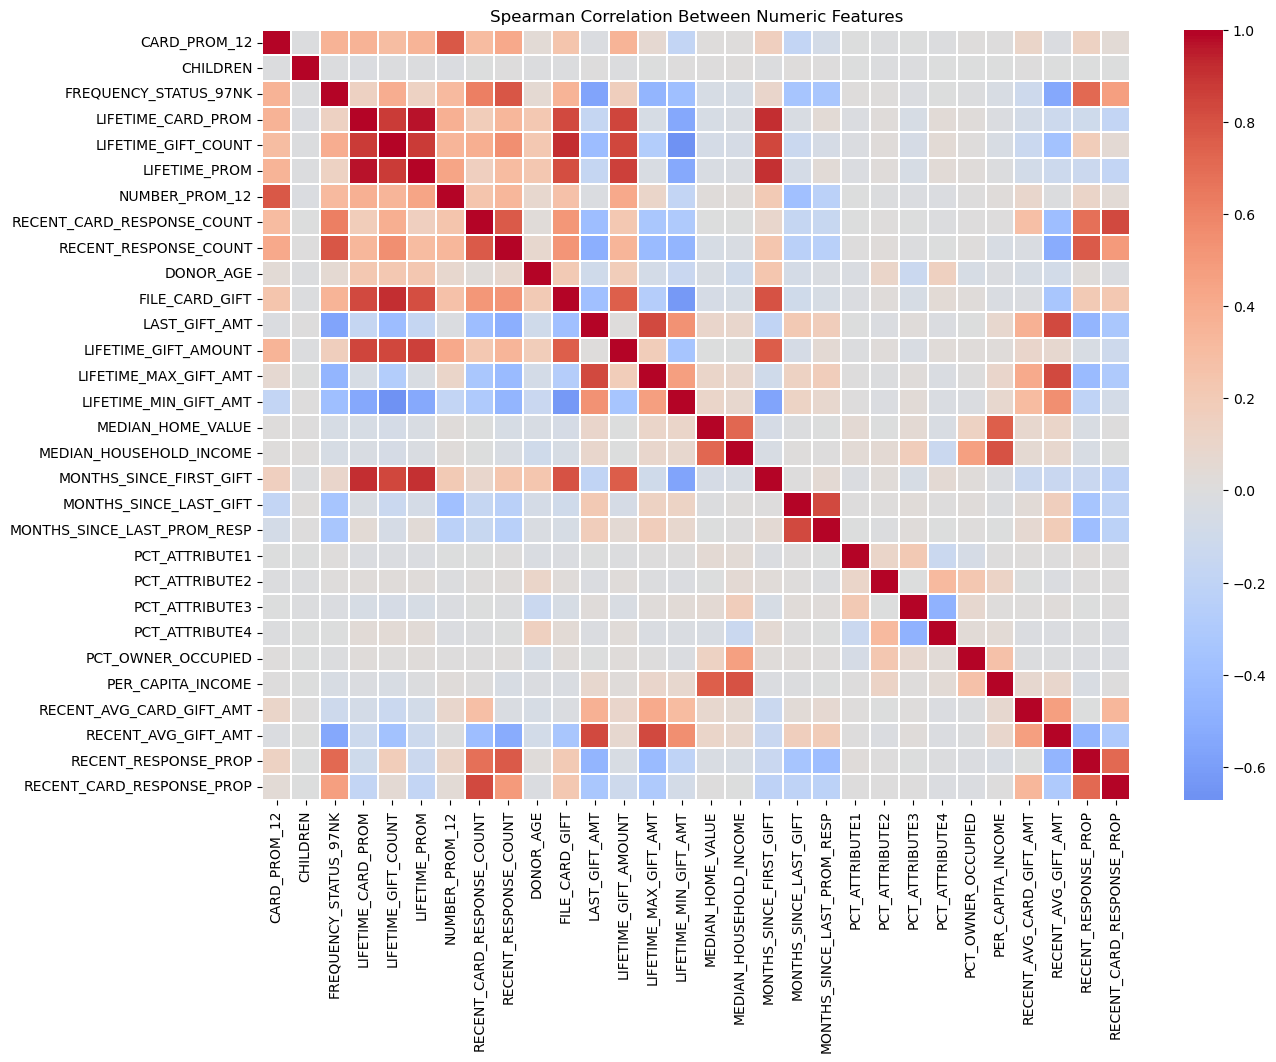

In [92]:
col_num = col_numdis + col_numcon

corr_spearman = train_clean[col_num].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(corr_spearman, cmap='coolwarm', center=0, linewidths=0.1)
plt.title("Spearman Correlation Between Numeric Features")
plt.show()

In [93]:
corr_pairs = (
    corr_spearman.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]  # remove self-correlations
corr_pairs.head(15)

LIFETIME_CARD_PROM       LIFETIME_PROM              0.970734
LIFETIME_PROM            LIFETIME_CARD_PROM         0.970734
LIFETIME_CARD_PROM       MONTHS_SINCE_FIRST_GIFT    0.919837
MONTHS_SINCE_FIRST_GIFT  LIFETIME_CARD_PROM         0.919837
LIFETIME_GIFT_COUNT      FILE_CARD_GIFT             0.918631
FILE_CARD_GIFT           LIFETIME_GIFT_COUNT        0.918631
MONTHS_SINCE_FIRST_GIFT  LIFETIME_PROM              0.902601
LIFETIME_PROM            MONTHS_SINCE_FIRST_GIFT    0.902601
                         LIFETIME_GIFT_COUNT        0.881704
LIFETIME_GIFT_COUNT      LIFETIME_PROM              0.881704
LIFETIME_CARD_PROM       LIFETIME_GIFT_COUNT        0.881387
LIFETIME_GIFT_COUNT      LIFETIME_CARD_PROM         0.881387
LIFETIME_GIFT_AMOUNT     LIFETIME_PROM              0.862827
LIFETIME_PROM            LIFETIME_GIFT_AMOUNT       0.862827
LIFETIME_GIFT_AMOUNT     LIFETIME_CARD_PROM         0.848266
dtype: float64

**Findings:**
- **Lifetime Donation Features**
    - **`LIFETIME_CARD_PROM`**, **`LIFETIME_GIFT_COUNT`**, **`LIFETIME_PROM`**, **`FILE_CARD_GIFT`**, **`LIFETIME_GIFT_AMOUNT`**, **`MONTHS_SINCE_FIRST_GIFT`**
    - Correlation identified between Lifetime donation activity features
    - Indicates some redundancy, deliberate which features to include in the modeling steps
- **Recent Response Features**
    - **`RECENT_RESPONSE_COUNT`**, **`RECENT_CARD_RESPONSE_COUNT`**, **`RECENT_RESPONSE_PROP`**, **`RECENT_CARD_RESPONSE_PROP`**, **`FREQUENCY_STATUS_97NK`**
    - Are also strongly correlated. Important because recent behaviour is likely predictive.
    - Features may be carry overlapping information.    
- **Gift Amount Features**
    - **`LAST_GIFT_AMT`**, **`LIFETIME_MAX_GIFT_AMT`**, **`RECENT_AVG_GIFT_AMT`**, **`RECENT_AVG_CARD_GIFT_AMT`**, **`LIFETIME_MIN_GIFT_AMT`**
    - Have moderate to strong relationships. Important because recent behaviour is likely predictive.
    - Features might not be interchangeable, each might capture a different donor behavior, test a decide inclusion in model.


- **Isolated Features**
    - **`CHILDREN`**, **`DONOR_AGE`**, **`PCT_ATTRIBUTE1`**, **`PCT_ATTRIBUTE2`**, **`PCT_ATTRIBUTE3`**, **`PCT_ATTRIBUTE4`**, **`PCT_OWNER_OCCUPIED`**, **`MEDIAN_HOME_VALUE`**<br>
        , **`MEDIAN_HOUSEHOLD_INCOME`**, **`PER_CAPITA_INCOME`**
    - No strong correlations with other features. They might add interesting idependant information, such as demographic and geographic context

##### **Preprocess Decision**
- **Feature Engineering sugestion:**
    - Create Features:
        - **`AVERAGE_GIFT_AMOUNT`** = **`LIFETIME_GIFT_AMOUNT`** / **`LIFETIME_GIFT_COUNT`**
        - **`PROM_EFFICIENCY`** = **`LIFETIME_GIFT_COUNT`** / **`LIFETIME_PROM`**

In [94]:
import math

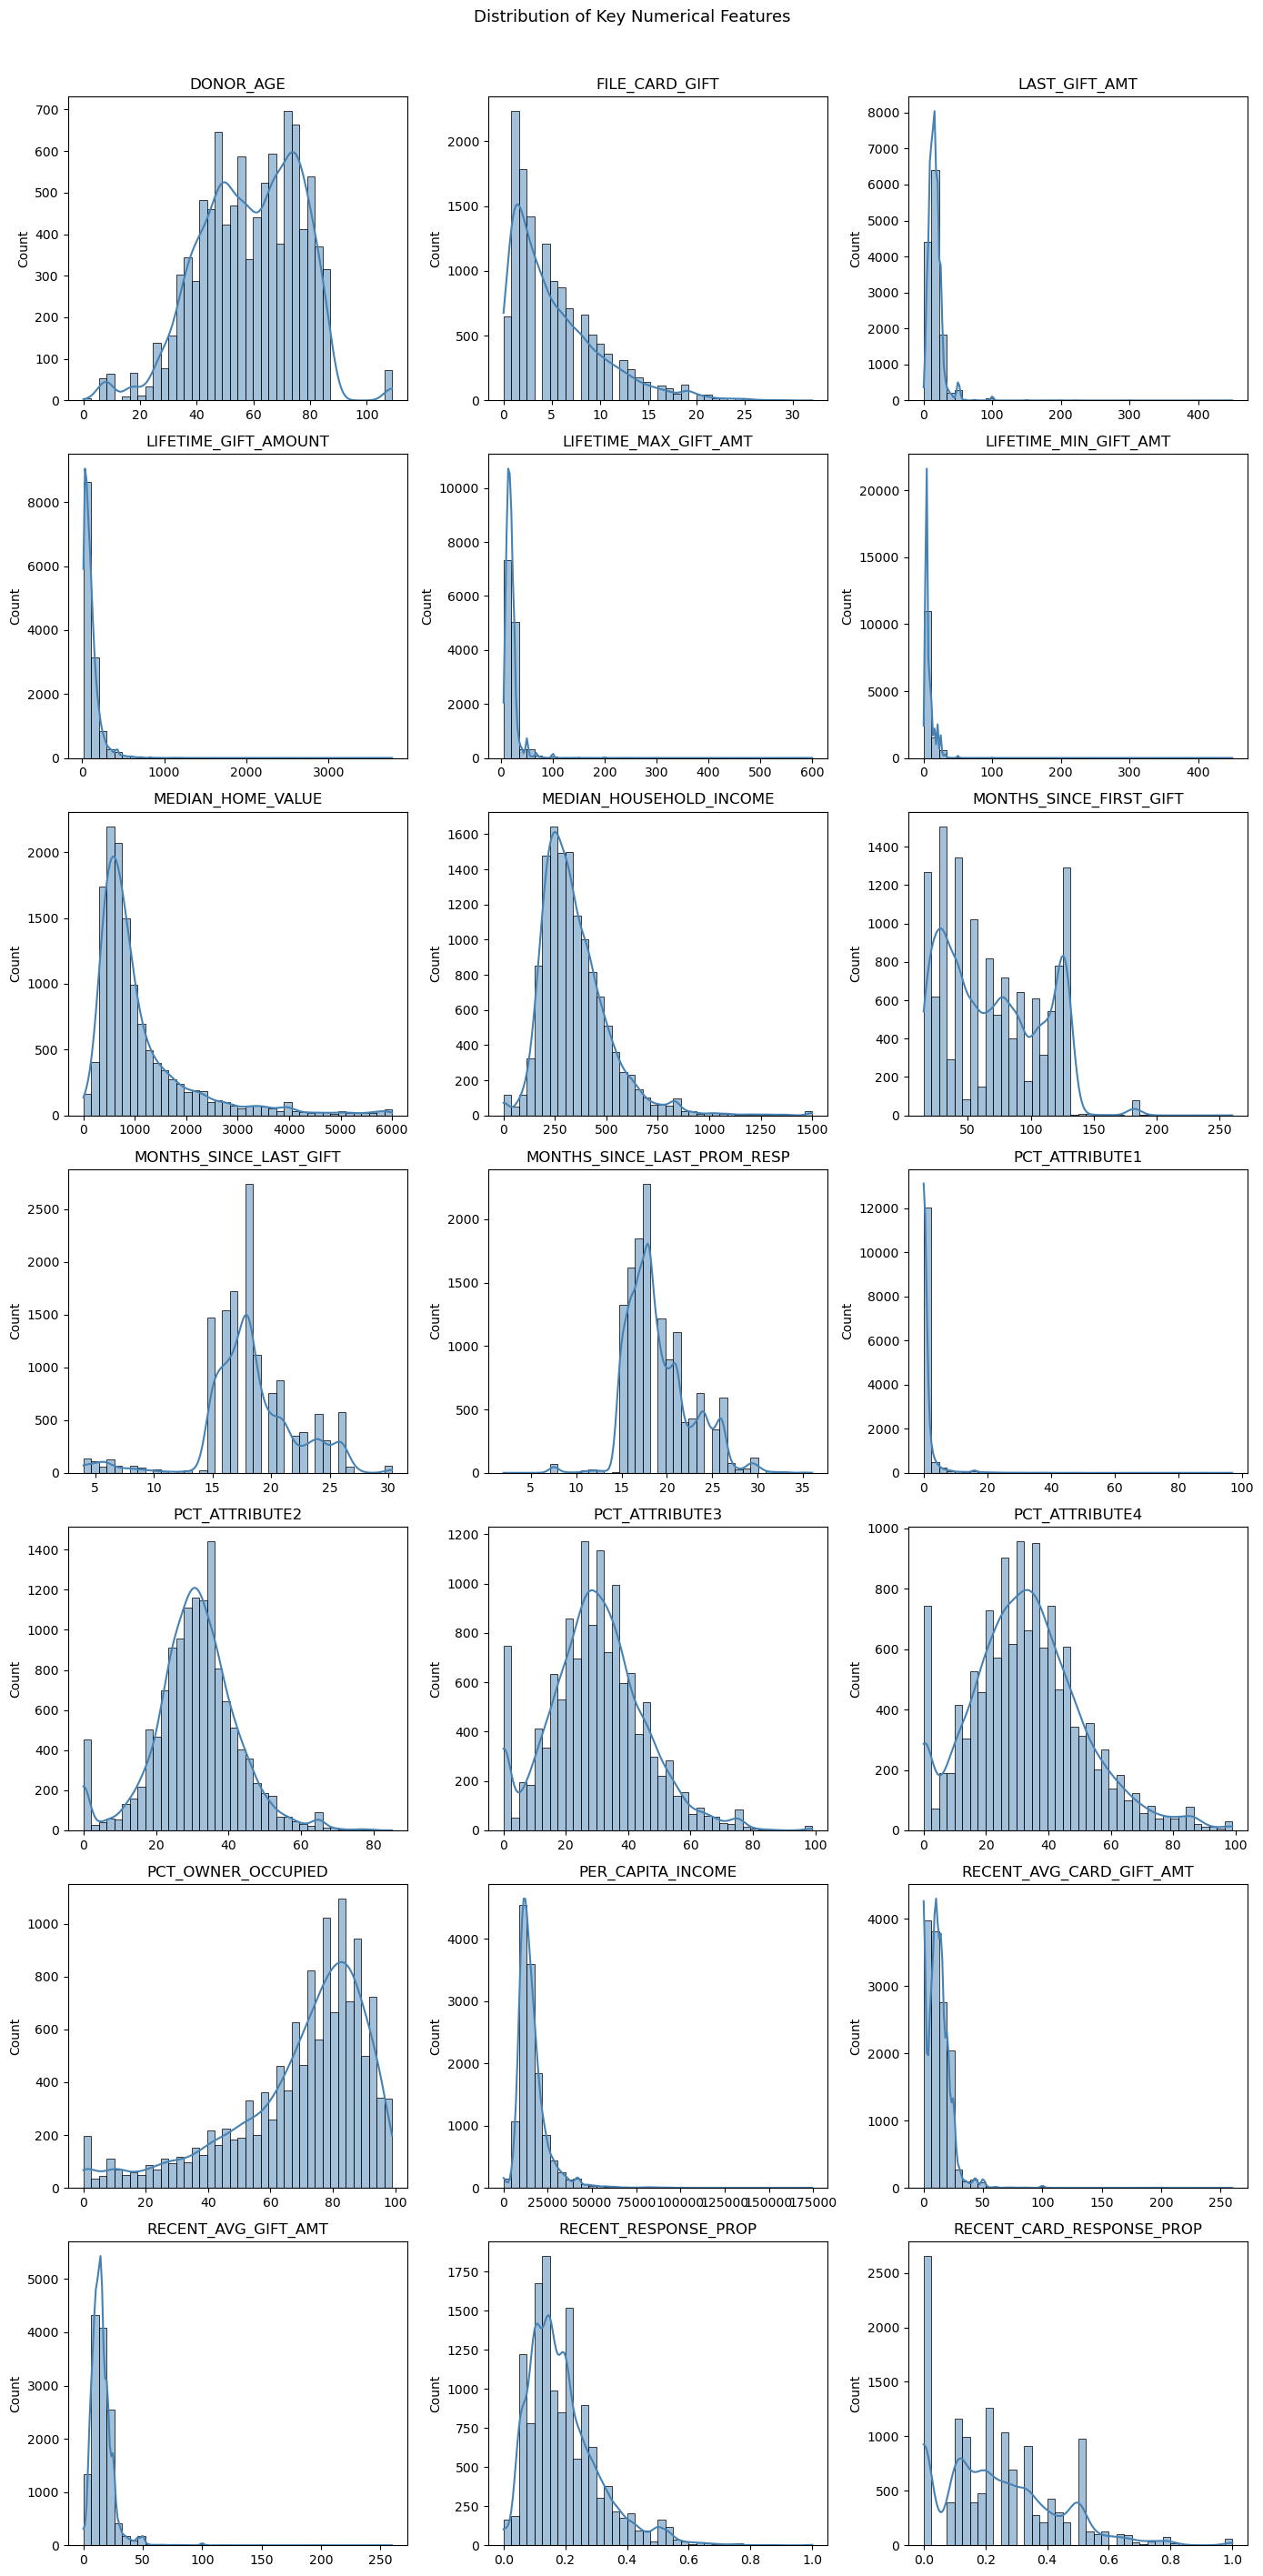

In [95]:

key_num = col_numcon

n_cols = 3
n_plots = len(key_num)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))

# Make axes always iterable, even if there is only 1 row
axes = axes.flatten()

for ax, col in zip(axes, key_num):
    sns.histplot(
        train_clean[col].dropna(),
        bins=40,
        ax=ax,
        color="steelblue",
        kde=True
    )
    ax.set_title(col)
    ax.set_xlabel("")

# Hide empty subplots
for ax in axes[n_plots:]:
    ax.set_visible(False)

plt.suptitle("Distribution of Key Numerical Features", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

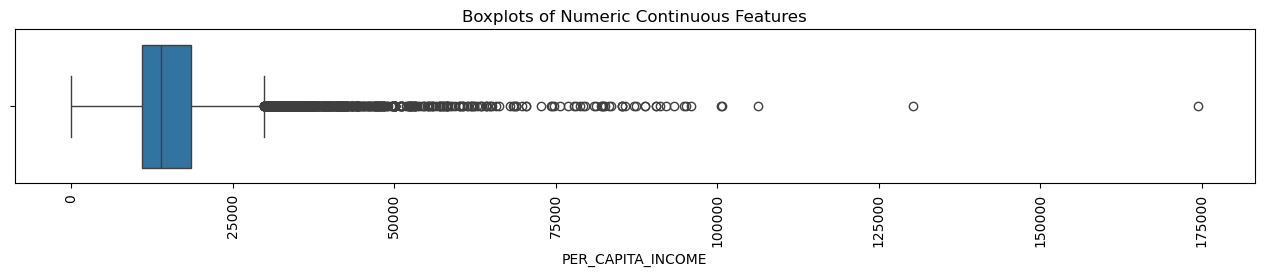

In [96]:

plt.figure(figsize=(16, 2))
sns.boxplot(x=train_clean['PER_CAPITA_INCOME'])
plt.xticks(rotation=90)
plt.title("Boxplots of Numeric Continuous Features")
plt.xlabel("PER_CAPITA_INCOME")
plt.show()

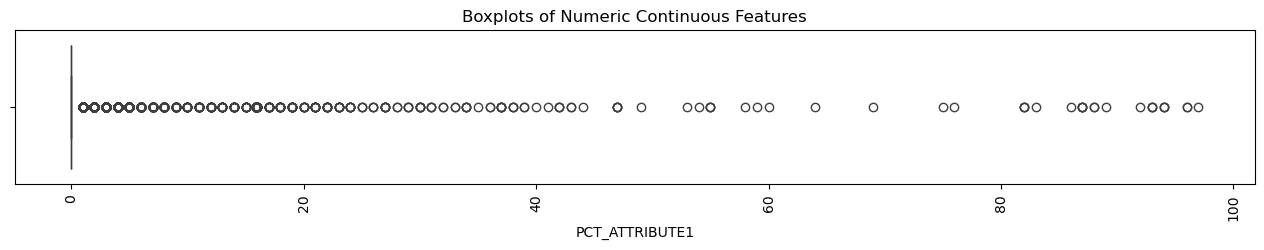

In [97]:

plt.figure(figsize=(16, 2))
sns.boxplot(x=train_clean['PCT_ATTRIBUTE1'])
plt.xticks(rotation=90)
plt.title("Boxplots of Numeric Continuous Features")
plt.xlabel("PCT_ATTRIBUTE1")
plt.show()

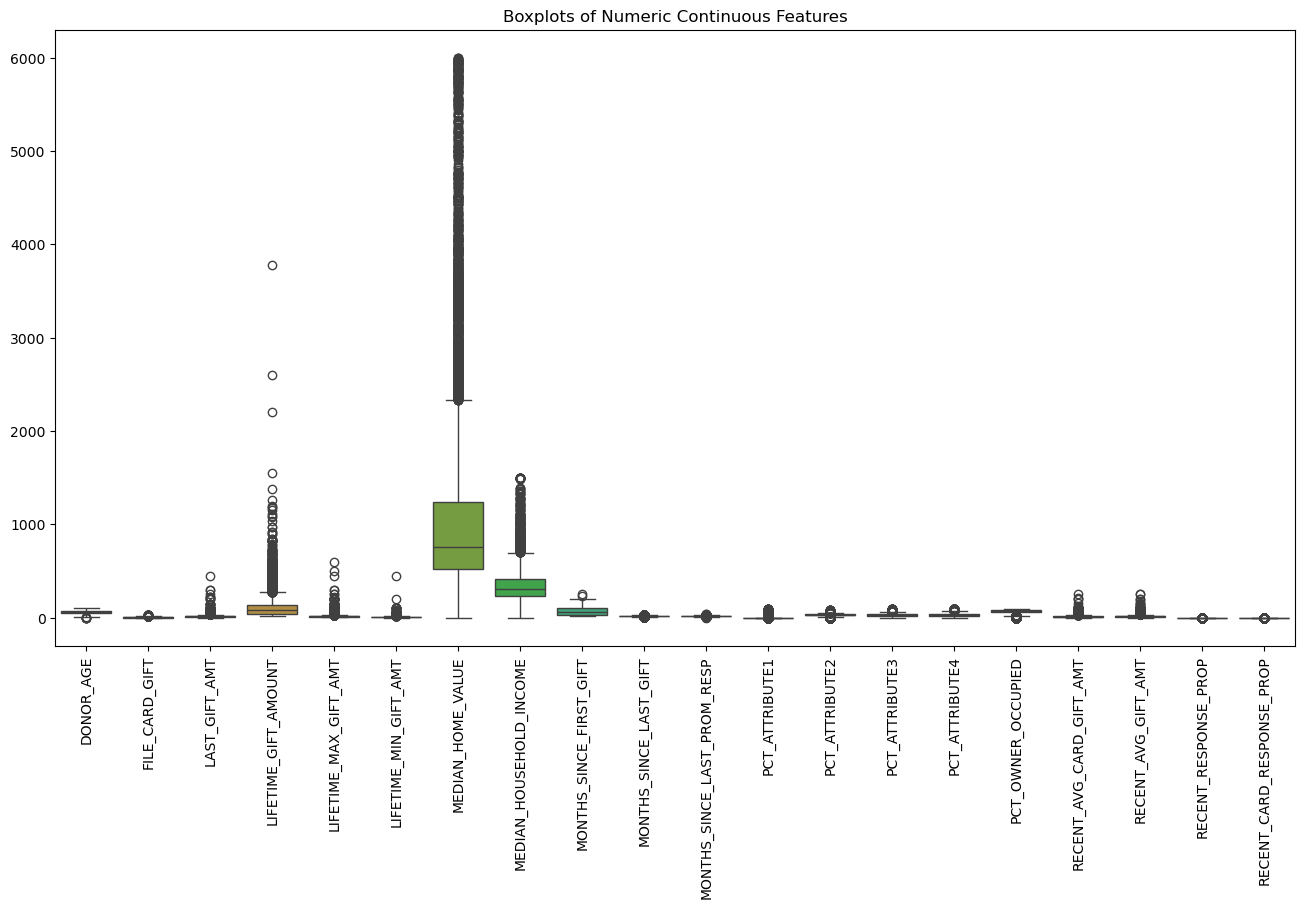

In [98]:
col_numcon_boxplot = [col for col in col_numcon if col != 'PER_CAPITA_INCOME']
plt.figure(figsize=(16, 8))
sns.boxplot(data=train_clean[col_numcon_boxplot])
plt.xticks(rotation=90)
plt.title("Boxplots of Numeric Continuous Features")
plt.show()

###### **`NOTES`**
**`NOTES`**
- The Graph are to maybe use justigy the application of different transformations
- boxplot where for exploration, probably remove them

In [99]:
# TODO: add your own EDA here (distributions, target relationships, categorical checks).
# Keep only the plots/tables that lead to a decision you explain in markdown.

## II.2 Preprocessing

The baseline pipeline below is deliberate but simple:

- **Numeric features** — median imputation, then standard scaling. Scaling is required by
  KNN and the neural network (distance / gradient based); it is harmless for trees.
- **Categorical features** — most-frequent imputation, then one-hot encoding.

All steps are wrapped in a `Pipeline`, so they are **fit on training folds only** during
cross-validation — this prevents data leakage.

> **`TODO`** Revisit these choices using your EDA. For example: `WEALTH_RATING` is ~46%
> missing — is median imputation honest, or is a "missing" indicator / dropping it
> better? Justify whatever you choose.

In [101]:
train_clean = clean_dataframe(train).copy()

In [118]:
# testing this, to check the inclusion of cleaning function inside preprocessor
from sklearn.preprocessing import FunctionTransformer

In [103]:
# Clean Dataset
train_clean = clean_dataframe(train).copy()
# Separate predictors from target / id
X = train_clean.drop(columns=[ID_COL, TARGET])
y = train_clean[TARGET].astype(int)
#X_test = test.drop(columns=[ID_COL])

#num_cols = X.select_dtypes(include="number").columns.tolist()
#cat_cols = X.select_dtypes(exclude="number").columns.tolist()

#SUGGESTION
cat_cols = col_catbin + col_catnom + col_catord
num_cols = col_numcon + col_numdis

print(f"{len(num_cols)} numeric | {len(cat_cols)} categorical: {cat_cols}")

# Cleaning Function wrapper
def clean_transformer_func(df):
    return clean_dataframe(df.copy())

def make_preprocessor():
    #\"\"\"Build the column-wise preprocessing transformer (no leakage: fit inside CV).\"\"\"
    #Cleans Data
    cleaner = FunctionTransformer(clean_transformer_func, validate=False)
    
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ])

    column_preprocessor = ColumnTransformer([
        ("num", numeric, num_cols),
        ("cat", categorical, cat_cols),
    ])
    

    return Pipeline([
        ("clean", cleaner),
        ("columns", column_preprocessor),
    ])

30 numeric | 9 categorical: ['PEP_STAR', 'RECENT_STAR_STATUS', 'HOME_OWNER', 'DONOR_GENDER', 'RECENCY_STATUS_96NK', 'URBANICITY', 'INCOME_GROUP', 'SES', 'WEALTH_RATING']


In [106]:
preprocessor = make_preprocessor()

In [107]:
preprocessor.fit(X)

,steps,"[('clean', ...), ('columns', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cle...001F3DC369B20>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [119]:

X_processed = preprocessor.transform(X)
feature_names = preprocessor.named_steps["columns"].get_feature_names_out()
X_processed_df = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed,
    columns=feature_names,
    index=X.index
)
X_processed_df

,num__DONOR_AGE,num__FILE_CARD_GIFT,num__LAST_GIFT_AMT,num__LIFETIME_GIFT_AMOUNT,num__LIFETIME_MAX_GIFT_AMT,num__LIFETIME_MIN_GIFT_AMT,num__MEDIAN_HOME_VALUE,num__MEDIAN_HOUSEHOLD_INCOME,num__MONTHS_SINCE_FIRST_GIFT,num__MONTHS_SINCE_LAST_GIFT,num__MONTHS_SINCE_LAST_PROM_RESP,num__PCT_ATTRIBUTE1,num__PCT_ATTRIBUTE2,num__PCT_ATTRIBUTE3,num__PCT_ATTRIBUTE4,num__PCT_OWNER_OCCUPIED,num__PER_CAPITA_INCOME,num__RECENT_AVG_CARD_GIFT_AMT,num__RECENT_AVG_GIFT_AMT,num__RECENT_RESPONSE_PROP,num__RECENT_CARD_RESPONSE_PROP,num__CARD_PROM_12,num__CHILDREN,num__FREQUENCY_STATUS_97NK,num__LIFETIME_CARD_PROM,...,cat__URBANICITY_R,cat__URBANICITY_S,cat__URBANICITY_T,cat__URBANICITY_U,cat__INCOME_GROUP_1.0,cat__INCOME_GROUP_2.0,cat__INCOME_GROUP_3.0,cat__INCOME_GROUP_4.0,cat__INCOME_GROUP_5.0,cat__INCOME_GROUP_6.0,cat__INCOME_GROUP_7.0,cat__SES_1,cat__SES_2,cat__SES_3,cat__SES_4,cat__WEALTH_RATING_0.0,cat__WEALTH_RATING_1.0,cat__WEALTH_RATING_2.0,cat__WEALTH_RATING_3.0,cat__WEALTH_RATING_4.0,cat__WEALTH_RATING_5.0,cat__WEALTH_RATING_6.0,cat__WEALTH_RATING_7.0,cat__WEALTH_RATING_8.0,cat__WEALTH_RATING_9.0
0,-1.735907,-1.138796,0.257419,-0.655069,0.038226,0.875118,-0.537694,-0.177400,-1.102584,-0.048493,-0.295788,-0.215005,1.838493,-0.849237,-0.450874,1.031409,-0.357196,-1.098432,0.188735,-0.327658,-1.241328,-1.110744,-0.005412,-0.914729,-1.143032,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.055069,-0.923733,-0.142415,-0.839355,-0.288008,0.875118,-0.794326,-1.178423,-1.208245,1.401977,1.435370,-0.215005,2.956687,0.074492,0.329488,0.161645,-0.923257,0.289472,-0.052984,-0.795259,0.083350,-1.906648,-0.005412,-0.914729,-1.499449,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.983723,0.366642,-0.542249,-0.249639,-0.483748,-0.331418,0.603701,0.170261,1.565367,-0.773728,-1.161368,-0.215005,-0.420806,0.602337,0.273748,0.665193,-0.229383,-1.098432,-0.471641,0.339108,-1.241328,-1.110744,-1.444372,0.927773,-0.192586,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.121401,1.657018,-0.462282,-0.240425,-0.548995,-0.572725,0.391565,0.859588,1.591782,-0.531983,-0.872841,-0.215005,1.490908,0.008511,0.608189,0.253199,0.911498,-0.173163,-0.536422,-0.700007,0.274104,-1.110744,1.433548,-0.914729,1.114277,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.050056,-0.493608,-0.782150,-0.728783,-0.809982,-0.331418,-0.154814,-0.573014,-1.208245,-0.290238,-0.584315,-0.215005,1.838493,-1.179140,1.834472,0.939855,-0.112240,-0.573804,-0.981185,2.668457,1.937900,0.481064,0.714068,1.849024,-1.143032,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13555,1.647047,0.151580,-0.542249,0.266362,0.038226,-0.331418,-0.545972,-0.357224,0.720076,0.193252,-0.007262,-0.215005,0.013674,-0.255411,2.391874,0.573638,-0.157727,-0.173163,-0.536422,-0.215087,-0.711457,-0.314840,-1.444372,-0.914729,1.589500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13556,1.779712,2.302205,-0.542249,0.727077,-0.288008,-0.572725,0.031451,-0.189388,1.591782,-0.290238,-0.584315,-0.215005,0.969532,0.668317,-0.172173,-1.532107,0.659691,-0.173163,-0.778141,0.165922,-0.065014,1.276968,-0.724892,0.927773,1.708306,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13557,0.055069,-0.708670,-0.542249,-0.599783,-0.614241,-0.331418,-0.687741,-1.052546,-0.944092,-0.290238,-0.584315,-0.023838,-0.681495,-0.585315,0.831150,-1.715215,-1.072409,-0.311953,-0.633110,0.373745,0.083350,0.481064,-0.005412,0.927773,-0.786615,...,0.0,0

In [109]:
# Separate predictors from target / id
X = train.drop(columns=[ID_COL, TARGET])
y = train[TARGET].astype(int)
X_test = test.drop(columns=[ID_COL])

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()


print(f"{len(num_cols)} numeric | {len(cat_cols)} categorical: {cat_cols}")

def make_preprocessor():
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ])
   
    return ColumnTransformer([
        ("num", numeric, num_cols),
        ("cat", categorical, cat_cols),
    ])

34 numeric | 5 categorical: ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']


# III. Binary Classification & Optimization

## III.1 Model assessment strategy and metric helpers

The helpers below evaluate any model with stratified 5-fold CV and report F1 (primary),
plus precision, recall, accuracy, and ROC-AUC for context.

`tune_threshold` is the key optimization lever: `predict()` cuts probabilities at 0.5,
but 0.5 rarely maximizes F1 on imbalanced data. We sweep thresholds on **out-of-fold**
probabilities and pick the F1-maximizing one — an honest, leakage-free estimate.

In [110]:
def evaluate_cv(model, X, y, cv=cv, label="model"):
    """Stratified CV evaluation. Returns a one-row summary DataFrame."""
    scoring = ["f1", "precision", "recall", "accuracy", "roc_auc"]
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": label}
    for s in scoring:
        row[f"{s}"] = res[f"test_{s}"].mean()
        row[f"{s}_std"] = res[f"test_{s}"].std()
    return pd.DataFrame([row])


def tune_threshold(model, X, y, cv=cv):
    """Find the decision threshold that maximizes F1 on out-of-fold probabilities."""
    proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    thresholds = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y, (proba >= t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1s))]
    return best_t, max(f1s), proba


def plot_hyperparam(values, train_scores, val_scores, xlabel, title):
    """Train-vs-validation curve to read under/overfitting (one plot per hyperparameter)."""
    plt.figure(figsize=(7, 4))
    plt.plot(values, train_scores, "o-", label="train F1")
    plt.plot(values, val_scores, "o-", label="validation F1")
    plt.xlabel(xlabel); plt.ylabel("F1 score"); plt.title(title)
    plt.legend(); plt.grid(alpha=.3); plt.show()

## III.2 Baseline models

Per the course material, every real model must beat two trivial baselines:

- **ZeroR** — always predicts the majority class. No predictive power; defines the floor.
- **OneR** — a one-level rule (here, a depth-1 decision tree). Best single-feature rule.

If a tuned model cannot beat these, it is not worth its complexity.

In [111]:
results = []  # collects the CV summary of every model

zeror = Pipeline([("prep", make_preprocessor()),
                  ("clf", DummyClassifier(strategy="most_frequent"))])
oner  = Pipeline([("prep", make_preprocessor()),
                  ("clf", DecisionTreeClassifier(max_depth=1, random_state=RANDOM_SEED))])

results.append(evaluate_cv(zeror, X, y, label="ZeroR"))
results.append(evaluate_cv(oner,  X, y, label="OneR"))
pd.concat(results, ignore_index=True)

,model,f1,f1_std,precision,precision_std,recall,recall_std,accuracy,accuracy_std,roc_auc,roc_auc_std
0,ZeroR,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.0,0.500000,0.000000
1,OneR,0.0,0.0,0.0,0.0,0.0,0.0,0.75,0.0,0.559292,0.006941


## III.3 Feature selection strategy

We score features with three complementary method families (per the Feature Selection
lecture) and keep features by **consensus**:

- **Filter** — ANOVA F-test (`f_classif`): each feature vs. the target, model-free.
- **Wrapper** — Recursive Feature Elimination (RFE) driven by logistic regression.
- **Embedded** — L1-penalised logistic regression; coefficients shrunk to ~0 are dropped.

> **`TODO`** Decide your keep-rule and *justify it*. "Keep if selected by ≥2 methods" is
> a reasonable majority vote; "keep if selected at least once" is more permissive.
> Note: doing selection once on the full training set (rather than inside each CV fold)
> slightly optimistically biases results — acceptable here, but mention it.

In [112]:
# Build a numeric design matrix once for the selectors (impute+encode+scale, no CV split).
prep_fs = make_preprocessor()
X_fs = prep_fs.fit_transform(X, y)
feat_names = prep_fs.get_feature_names_out()
X_fs = pd.DataFrame(X_fs.toarray() if hasattr(X_fs, "toarray") else X_fs,
                    columns=feat_names)

vote = pd.DataFrame(index=feat_names)

# 1) Filter: ANOVA F-score -> keep top half
f_scores, _ = f_classif(X_fs, y)
vote["anova"] = (pd.Series(f_scores, index=feat_names)
                 .rank(ascending=False) <= len(feat_names) / 2).astype(int)

# 2) Wrapper: RFE with logistic regression -> keep top half
rfe = RFE(LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
          n_features_to_select=len(feat_names) // 2)
rfe.fit(X_fs, y)
vote["rfe"] = rfe.support_.astype(int)

# 3) Embedded: L1 logistic regression -> keep non-zero coefficients
l1 = LogisticRegression(penalty="l1", solver="liblinear",
                        max_iter=1000, random_state=RANDOM_SEED).fit(X_fs, y)
vote["lasso"] = (np.abs(l1.coef_[0]) > 1e-6).astype(int)

vote["votes"] = vote.sum(axis=1)
vote.sort_values("votes", ascending=False)

,anova,rfe,lasso,votes
num__RECENT_CARD_RESPONSE_COUNT,1,1,1,3
num__LIFETIME_MAX_GIFT_AMT,1,1,1,3
num__RECENT_AVG_GIFT_AMT,1,1,1,3
num__RECENT_CARD_RESPONSE_PROP,1,1,1,3
num__RECENT_RESPONSE_COUNT,1,1,1,3
num__RECENT_RESPONSE_PROP,1,1,1,3
num__MONTHS_SINCE_LAST_GIFT,1,1,1,3
num__MONTHS_SINCE_FIRST_GIFT,1,1,1,3
num__MEDIAN_HOME_VALUE,1,1,1,3
cat__RECENCY_STATUS_96NK_F,1,1,1,3


In [113]:
# TODO: set your keep-rule. Default = majority vote (selected by >=2 of 3 methods).
selected_features = vote.index[vote["votes"] >= 2].tolist()
print(f"{len(selected_features)} / {len(feat_names)} features kept by consensus")

38 / 56 features kept by consensus


## III.4 Candidate models and hyperparameter tuning

Three models from the course, each with its key hyperparameter:

- **KNN** — `n_neighbors`
- **Decision Tree** — `max_depth` (plus pruning options)
- **Neural Network** (`MLPClassifier`) — `hidden_layer_sizes`

For each, we sweep the hyperparameter and read the train-vs-validation gap to spot
under/overfitting.

> **`TODO`** Widen the search grids, tune secondary hyperparameters (KNN `weights`;
> tree `min_samples_leaf`, `ccp_alpha`; NN `alpha`), and consider `class_weight='balanced'`
> for the tree to address the 25/75 imbalance.

In [114]:
def cv_train_val_f1(model, X, y, cv=cv):
    """Return mean train-fold and validation-fold F1 for one model."""
    res = cross_validate(model, X, y, cv=cv, scoring="f1",
                         return_train_score=True, n_jobs=-1)
    return res["train_score"].mean(), res["test_score"].mean()


def sweep(make_model, grid, X, y, xlabel, title):
    """Sweep one hyperparameter; plot train/val F1; return per-value val scores."""
    tr, va = [], []
    for v in grid:
        t, s = cv_train_val_f1(make_model(v), X, y)
        tr.append(t); va.append(s)
    plot_hyperparam(grid, tr, va, xlabel, title)
    return dict(zip(grid, va))

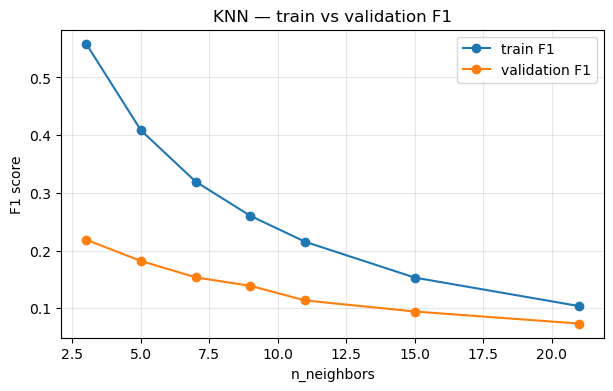

best n_neighbors: 3


In [115]:
# --- KNN: sweep n_neighbors ---
knn_grid = [3, 5, 7, 9, 11, 15, 21]
knn_val = sweep(
    lambda k: Pipeline([("prep", make_preprocessor()),
                        ("clf", KNeighborsClassifier(n_neighbors=k))]),
    knn_grid, X, y, "n_neighbors", "KNN — train vs validation F1")
best_k = max(knn_val, key=knn_val.get)
print("best n_neighbors:", best_k)

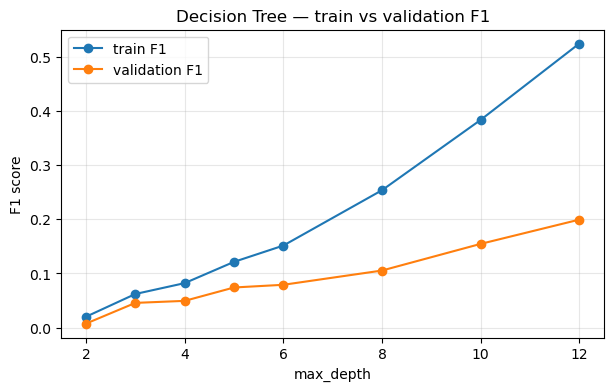

best max_depth: 12


In [116]:
# --- Decision Tree: sweep max_depth ---
dt_grid = [2, 3, 4, 5, 6, 8, 10, 12]
dt_val = sweep(
    lambda d: Pipeline([("prep", make_preprocessor()),
                        ("clf", DecisionTreeClassifier(max_depth=d,
                                                       random_state=RANDOM_SEED))]),
    dt_grid, X, y, "max_depth", "Decision Tree — train vs validation F1")
best_depth = max(dt_val, key=dt_val.get)
print("best max_depth:", best_depth)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (4,) + inhomogeneous part.

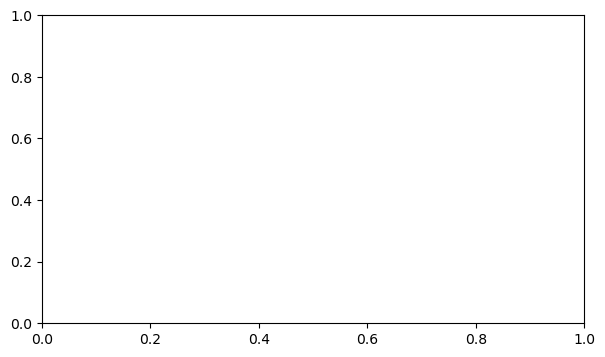

In [117]:
# --- Neural Network: sweep hidden_layer_sizes ---
nn_grid = [(16,), (32,), (64,), (32, 16)]
nn_val = sweep(
    lambda h: Pipeline([("prep", make_preprocessor()),
                        ("clf", MLPClassifier(hidden_layer_sizes=h, max_iter=300,
                                              random_state=RANDOM_SEED))]),
    nn_grid, X, y, "hidden_layer_sizes", "Neural Network — train vs validation F1")
best_arch = max(nn_val, key=nn_val.get)
print("best hidden_layer_sizes:", best_arch)

## III.5 Model comparison

All candidates evaluated with the same stratified CV and the same metrics. Selection is
on **F1**; ROC-AUC is a secondary, threshold-independent view.

> **`TODO`** Discuss the table: which model generalizes best, are the differences larger
> than the std (i.e. real), and what trade-offs (precision vs recall) do you see.

In [ ]:
candidates = {
    "KNN":          Pipeline([("prep", make_preprocessor()),
                              ("clf", KNeighborsClassifier(n_neighbors=best_k))]),
    "DecisionTree": Pipeline([("prep", make_preprocessor()),
                              ("clf", DecisionTreeClassifier(max_depth=best_depth,
                                                             random_state=RANDOM_SEED))]),
    "NeuralNet":    Pipeline([("prep", make_preprocessor()),
                              ("clf", MLPClassifier(hidden_layer_sizes=best_arch,
                                                    max_iter=300,
                                                    random_state=RANDOM_SEED))]),
}
for name, model in candidates.items():
    results.append(evaluate_cv(model, X, y, label=name))

summary = pd.concat(results, ignore_index=True)
summary.round(4)

## III.6 Optimization — decision threshold

We take the best candidate and tune its decision threshold to maximize F1, instead of
leaving it at the default 0.5.

> **`TODO`** Set `final_model` to your chosen model. Inspect the confusion matrix and
> the precision-recall curve at the tuned threshold, and discuss the chosen trade-off.

In [ ]:
# TODO: pick the model your comparison supports. Default = highest CV F1 among candidates.
best_name = summary.set_index("model").loc[list(candidates), "f1"].idxmax()
final_model = candidates[best_name]
print("selected model:", best_name)

best_t, best_f1, oof_proba = tune_threshold(final_model, X, y)
print(f"tuned threshold = {best_t:.3f}  ->  out-of-fold F1 = {best_f1:.4f}")

print("\nConfusion matrix at tuned threshold:")
print(confusion_matrix(y, (oof_proba >= best_t).astype(int)))
print("\n", classification_report(y, (oof_proba >= best_t).astype(int)))

# IV. Deployment

Refit the final model on **all** training data, predict the test set, apply the tuned
threshold, and write the Kaggle submission file.

> **`TODO`** Confirm the chosen model/threshold, then submit the CSV on Kaggle named
> `DSML_GroupXX`.

In [ ]:
final_model.fit(X, y)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_t).astype(int)

submission = pd.DataFrame({ID_COL: test[ID_COL], TARGET: test_pred})
out_path = DATA_DIR / "DSML_GroupXX_submission.csv"
submission.to_csv(out_path, index=False)
print(f"saved {out_path}  |  predicted positive rate: {test_pred.mean():.3f}")
submission.head()

# V. Open-Ended Section

> **`TODO`** Choose an objective that goes *beyond* adding/removing pipeline techniques.
> Strong fits given the vanilla-sklearn constraint:
> - **Model calibration** — calibration curve + Brier score (`CalibratedClassifierCV`);
>   pairs naturally with the probability/threshold work above.
> - **Error analysis** — characterise the misclassified donors: is there a pattern?
> - **Analytics interface** — a small function/widget returning a prediction for new input.
>
> State the objective, describe what you did, and discuss the findings.